In [1]:
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

from analysis_shared_functions import (
    bulk_vs_singlecell_matrix_viz, 
    all_samples_matrix_viz,
    parse_heatmap_matrix_hysys,
    long_df_to_matrix_hysys,
    parse_sample_matching_results_hysys,
    print_hysys_results_summary
)

In [2]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
tool = "HYSYS"
dataset = "low_grade_glioma"
pseudobulk = True
ncells = 500000
rd = 1

# Data munging

In [3]:
df, matrix = parse_heatmap_matrix_hysys(DATA_PATH, pseudobulk, dataset, ncells, rd)

In [4]:
matrix.head()

,pseudobulk_GSM7326880_ncells_500000_1,pseudobulk_GSM7326880_ncells_500000_2,pseudobulk_GSM7326880_ncells_500000_3,pseudobulk_GSM7326881_ncells_500000_1,pseudobulk_GSM7326881_ncells_500000_2,pseudobulk_GSM7326881_ncells_500000_3,pseudobulk_GSM7326883_ncells_500000_1,pseudobulk_GSM7326883_ncells_500000_2,pseudobulk_GSM7326883_ncells_500000_3,pseudobulk_GSM7326884_ncells_500000_1,...,pseudobulk_GSM7326901_ncells_500000_3,pseudobulk_GSM7326902_ncells_500000_1,pseudobulk_GSM7326902_ncells_500000_2,pseudobulk_GSM7326902_ncells_500000_3,pseudobulk_GSM7326903_ncells_500000_1,pseudobulk_GSM7326903_ncells_500000_2,pseudobulk_GSM7326903_ncells_500000_3,pseudobulk_GSM7326905_ncells_500000_1,pseudobulk_GSM7326905_ncells_500000_2,pseudobulk_GSM7326905_ncells_500000_3
0,,,,,,,,,,,,,,,,,,,,,
pseudobulk_GSM7326880_ncells_500000_1,1.000,1.000,1.000,0.012,0.012,0.012,0.001,0.001,0.001,0.013,...,0.002,0.002,0.002,0.002,0.003,0.003,0.003,0.001,0.001,0.001
pseudobulk_GSM7326880_ncells_500000_2,1.000,1.000,1.000,0.012,0.012,0.012,0.001,0.001,0.001,0.013,...,0.002,0.002,0.002,0.002,0.003,0.003,0.003,0.001,0.001,0.001
pseudobulk_GSM7326880_ncells_500000_3,1.000,1.000,1.000,0.012,0.012,0.012,0.001,0.001,0.001,0.013,...,0.002,0.002,0.002,0.002,0.003,0.003,0.003,0.001,0.001,0.001
pseudobulk_GSM7326881_ncells_500000_1,0.012,0.012,0.012,1.000,1.000,1.000,0.001,0.001,0.001,0.021,...,0.006,0.003,0.003,0.003,0.006,0.006,0.006,0.001,0.001,0.001
pseudobulk_GSM7326881_ncells_500000_2,0.012,0.012,0.012,1.000,1.000,1.000,0.001,0.001,0.001,0.021,...,0.006,0.003,0.003,0.003,0.006,0.006,0.006,0.001,0.001,0.001


In [5]:
df.head()

,Sample,Concordance,Size
0,,,
pseudobulk_GSM7326880_ncells_500000_1,pseudobulk_GSM7326880_ncells_500000_1,1.000,1380
pseudobulk_GSM7326880_ncells_500000_1,pseudobulk_GSM7326880_ncells_500000_2,1.000,1380
pseudobulk_GSM7326880_ncells_500000_1,pseudobulk_GSM7326880_ncells_500000_3,1.000,1380
pseudobulk_GSM7326880_ncells_500000_1,pseudobulk_GSM7326881_ncells_500000_1,0.012,3364
pseudobulk_GSM7326880_ncells_500000_1,pseudobulk_GSM7326881_ncells_500000_2,0.012,3364


In [3]:
sample_matches_df = parse_sample_matching_results_hysys(DATA_PATH, pseudobulk, dataset, ncells, rd)
sample_matches_df.head()

match
sample1                               sample2                                     
pseudobulk_GSM7326905_ncells_500000_2 pseudobulk_GSM7326905_ncells_500000_2      0
                                      pseudobulk_GSM7326903_ncells_500000_3      0
                                      pseudobulk_GSM7326895_ncells_500000_1      0
                                      pseudobulk_GSM7326894_ncells_500000_1      0
                                      pseudobulk_GSM7326886_ncells_500000_1      0

In [4]:
len(sample_matches_df)

4356

# Real data viz & analysis

## Comparison with expected matches

# Pseudobulk data viz & analysis

In [ ]:
# Filter HYSYS matrix to only samples ending in _1 in rows and samples ending in _2 in columns (or _2 vs _3 or _1 vs _3)
pseudobulk_1 = "_1"
pseudobulk_1_regex = r"_1$"
pseudobulk_2 = "_2"
pseudobulk_2_regex = r"_2$"
matrix_filtered = matrix.loc[
    [idx for idx in matrix.index if idx.endswith(pseudobulk_1)],
    [col for col in matrix.columns if col.endswith(pseudobulk_2)]
]

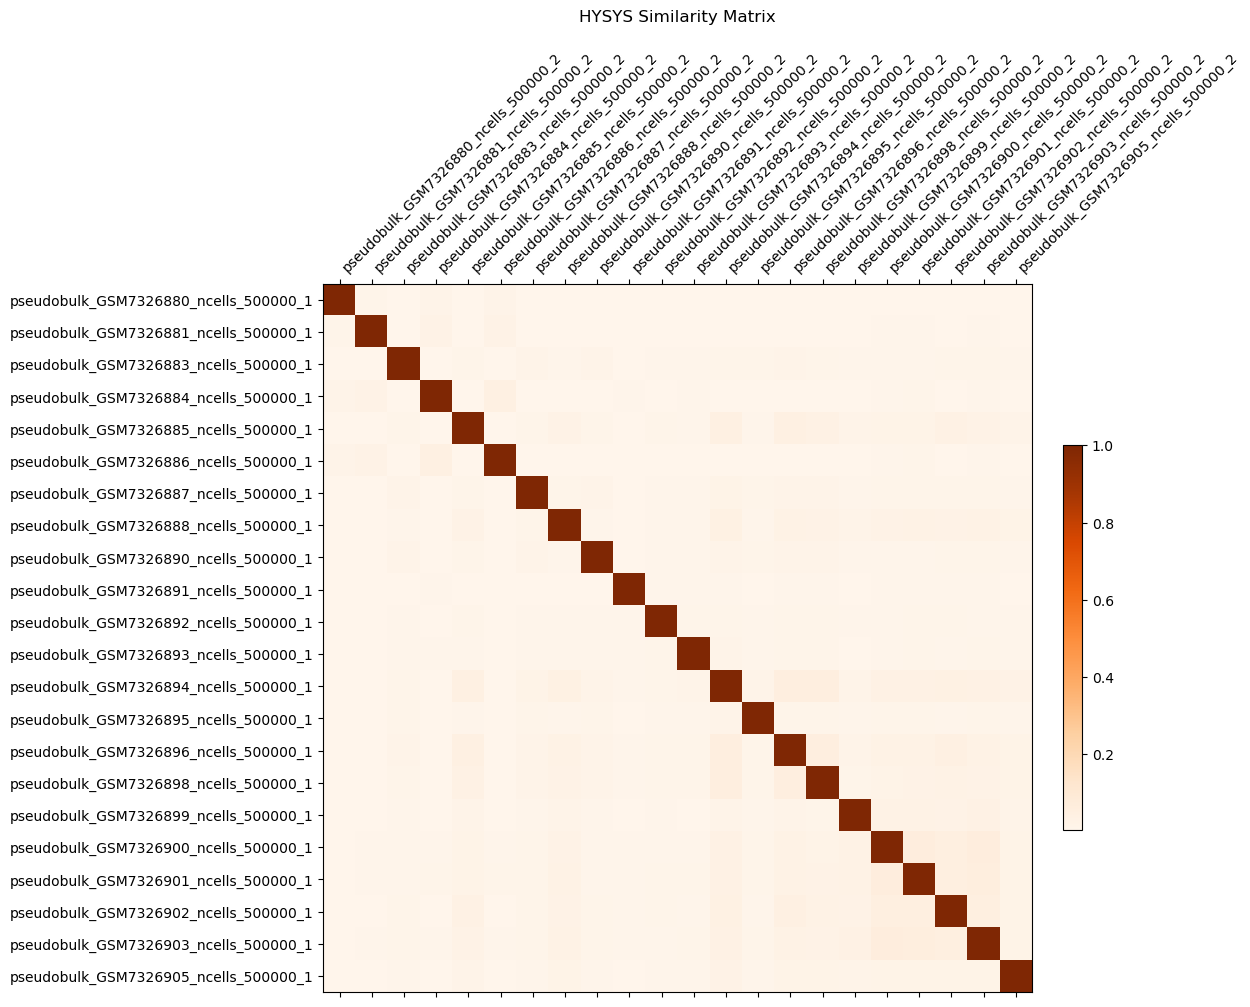

In [ ]:
all_samples_matrix_viz(
    matrix_filtered, 
    pseudobulk=pseudobulk, 
    tool=tool, 
    dataset=dataset, 
    ncells=ncells, 
    rd=rd, 
    save_fig=True,
    FIGURES_PATH=FIGURES_PATH
)

## Detailed accuracy metrics

In [16]:
sample_matches_df.head()

match
sample1                               sample2                                     
pseudobulk_GSM7326880_ncells_500000_1 pseudobulk_GSM7326880_ncells_500000_2      1
                                      pseudobulk_GSM7326880_ncells_500000_3      1
                                      pseudobulk_GSM7326881_ncells_500000_1      0
                                      pseudobulk_GSM7326881_ncells_500000_2      0
                                      pseudobulk_GSM7326881_ncells_500000_3      0

In [17]:
# Get all pairs where one sample ends with _1 and the other ends with _2
# Since itertools.combinations ensures consistent ordering, we need to check both possibilities
def has_one_suffix_each(sample1, sample2, suffix1, suffix2):
    """Check if one sample has suffix1 and the other has suffix2 (order doesn't matter)"""
    return ((sample1.endswith(suffix1) and sample2.endswith(suffix2)) or
            (sample1.endswith(suffix2) and sample2.endswith(suffix1)))

# Filter to get _1 vs _2 pairs (avoiding double counting)
mask = sample_matches_df.index.to_series().apply(
    lambda x: has_one_suffix_each(x[0], x[1], pseudobulk_1, pseudobulk_2)
)

hysys_pseudobulk_pairs = sample_matches_df[mask]

print(f"Found {len(hysys_pseudobulk_pairs)} unique pairs comparing _1 vs _2 pseudobulk samples")
print(f"Expected: 22 × 22 = 484 pairs")

Found 484 unique pairs comparing _1 vs _2 pseudobulk samples
Expected: 22 × 22 = 484 pairs


In [18]:
# Reorder pairs so that _1 samples are always in sample1 position and _2 samples in sample2 position
reordered_pairs = []

for (s1, s2), row in hysys_pseudobulk_pairs.iterrows():
    if s1.endswith('_1') and s2.endswith('_2'):
        # Already in correct order
        reordered_pairs.append({'sample1': s1, 'sample2': s2, 'match': row['match']})
    elif s1.endswith('_2') and s2.endswith('_1'):
        # Swap the order
        reordered_pairs.append({'sample1': s2, 'sample2': s1, 'match': row['match']})

# Create new DataFrame with consistent ordering
hysys_pseudobulk_pairs_reordered = pd.DataFrame(reordered_pairs)
hysys_pseudobulk_pairs_reordered = hysys_pseudobulk_pairs_reordered.set_index(['sample1', 'sample2'])

In [19]:
hysys_pseudobulk_pairs_reordered.head()

match
sample1                               sample2                                     
pseudobulk_GSM7326880_ncells_500000_1 pseudobulk_GSM7326880_ncells_500000_2      1
                                      pseudobulk_GSM7326881_ncells_500000_2      0
                                      pseudobulk_GSM7326883_ncells_500000_2      0
                                      pseudobulk_GSM7326884_ncells_500000_2      0
                                      pseudobulk_GSM7326885_ncells_500000_2      0

In [ ]:
# Create true_matches matrix for submatrix 
# Matches on the diagonal (1), the rest non-matches (0)
true_matches = pd.DataFrame(
    np.identity(len(matrix_filtered)),
    index=pd.Index(sorted(set(hysys_pseudobulk_pairs_reordered.index.get_level_values(0))), name="pseudobulk_1"), 
    columns=pd.Index(sorted(set(hysys_pseudobulk_pairs_reordered.index.get_level_values(1))), name="pseudobulk_2"),
    )

In [21]:
# Melt matrix into long form 
true_matches_long = true_matches.stack().rename("match").reset_index().set_index(["pseudobulk_1", "pseudobulk_2"])

In [22]:
# Calculate confusion matrix
tn, fp, fn, tp = confusion_matrix(true_matches_long, hysys_pseudobulk_pairs_reordered).ravel().tolist()

In [23]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)
balanced_accuracy = (tpr + tnr) / 2
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy = {accuracy:.2f}")
print(f"Balanced accuracy = {balanced_accuracy:.2f}")
print(f"Precision = {precision:.2f}")
print(f"Recall = {recall:.2f}")
print(f"F1 = {f1:.2f}")

Accuracy = 0.92
Balanced accuracy = 0.52
Precision = 0.09
Recall = 0.09
F1 = 0.09
